![Banner](https://i.imgur.com/a3uAqnb.png)

# Implement Oriented Bounding Box (OBB) Detection Using YOLO - Homework Assignment

![Architecture of the YOLOv11-OBB](https://www.researchgate.net/publication/393366901/figure/fig2/AS:11431281539704197@1752249585792/Architecture-of-the-YOLOv11-OBB-model.tif)

In this assignment, you will create a dataset class for a subset of the Dota OBB dataset and use oriented YOLO from ultralytics for detecting objects with oriented bounding boxes.

## 📌 Project Overview
- **Task**: Multi-class oriented object detection using DOTA dataset subset
- **Architecture**: YOLO variants with Oriented Bounding Box (OBB) detection
- **Dataset**: DOTA Demo dataset (58 images) from Roboflow
- **Goal**: Compare performance of different YOLO models for OBB detection

## 📚 Learning Objectives
By completing this assignment, you will:
- Understand oriented bounding box detection vs regular bounding boxes
- Learn about YOLO architecture variants (YOLOv8n, YOLOv8m, YOLO11n)
- Implement custom dataset classes for OBB data format
- Compare multiple model architectures on the same task
- Evaluate OBB detection models using specialized metrics
- Visualize oriented bounding box predictions

## 🎯 Evaluation Metrics
You will be evaluated using:
- **mAP@0.5**: Mean Average Precision at IoU threshold 0.5 for OBB
- **mAP@0.5:0.95**: Mean Average Precision across IoU thresholds 0.5-0.95
- **Precision**: Overall precision across all classes
- **Recall**: Overall recall across all classes
- **F1-Score**: Harmonic mean of precision and recall

## Dataset:
You will use a subset of DOTA Dataset, consisting of 58 images. Dataset can be downloaded from:
https://universe.roboflow.com/rotated-object-detection/dota-demo/dataset/1

## Tasks:
1. Create a dataset class for the above dataset
2. Select 3 different YOLO models from ultralytics (different YOLO versions)
3. Train all models on the training dataset
4. Evaluate all models on the test set
5. Plot predictions for all models on the same images

## 1️⃣ Dataset Setup and Library Imports

**Task**: Import necessary libraries and download the DOTA OBB dataset from Roboflow.

**Requirements**:
- Import all required libraries for computer vision, deep learning, and visualization
- Set up matplotlib configuration for consistent plotting
- Configure Roboflow API access with your personal API key
- Download the DOTA Demo dataset in YOLO OBB format
- Parse the dataset configuration file (data.yaml)


In [ ]:
# TODO: Import all necessary libraries for YOLO OBB training and evaluation

# install ultralytics first
!pip install ultralytics roboflow --quiet

import os
import zipfile
import torch
import yaml
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from roboflow import Roboflow
import cv2

# goto roboflow for download code!
# TODO: Initialize Roboflow with your API key
rf = Roboflow(api_key = "Dfv4WBvChWqSdADSJiLc")
# TODO: Download dataset version 1 in "yolov8-obb" format
project = rf.workspace("rotated-object-detection").project("dota-demo")
dataset = project.version(1).download("yolov8-obb", overwrite=True)
# TODO: Set up dataset paths
DATASET_PATH = dataset.location
DATA_PATH = os.path.join(dataset.location, "data.yaml")
# TODO: Load and parse the data.yaml configuration
with open(DATA_PATH, 'r') as f:
  data = yaml.safe_load(f)
# here, we need to update the directory
# otherwise, we will find: "missing path '/content/datasets/roboflow/valid/images'" error during training
data['path'] = '../DOTA-Demo-1'
with open(DATA_PATH, 'w') as f:
  yaml.dump(data, f)
# TODO: Print dataset information
print(f"Dataset downloaded to: {dataset.location}")
print(open(DATA_PATH).read())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 4.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to DOTA-Demo-1 in yolov8-obb:: 100%|██████████| 128/128 [00:00<00:00, 5057.09it/s]

Dataset downloaded to: /content/DOTA-Demo-1
names:
  0: harbor
  1: large-vehicle
  2: plane
  3: ship
  4: small-vehicle
path: ../DOTA-Demo-1
test: test/images
train: train/images
val: valid/images



## 2️⃣ Custom Dataset Class Implementation

**Task**: Create a comprehensive PyTorch Dataset class for DOTA OBB format.

**Requirements**:
- Inherit from torch.utils.data.Dataset
- Parse OBB annotations in YOLO format (normalized coordinates)
- Convert between normalized and pixel coordinates
- Implement visualization methods for oriented bounding boxes
- Handle different image formats (jpg, png) if needed
- Provide proper data validation and error handling

In [ ]:
# install Path
!pip install Path

In [ ]:
import os
from pathlib import Path
from torch.utils.data import Dataset
from torchvision import datasets, transforms
import random

# TODO: Implement DOTAOBBDataset class inheriting from Dataset
class DOTAOBBDataset(Dataset):
    # TODO: Implement __init__ method with parameters:
    #       - images_dir: str (path to images directory)
    #       - labels_dir: str (path to labels directory)
    #       - class_names: List[str] (list of class names)
    #       - transform=None (optional image transformations)
    #
    def __init__(self, images_dir: str, labels_dir: str, class_names: list[str], transform=None):
    # TODO: In __init__:
    #       - Convert directory paths to Path objects
    #       - Store class_names and calculate num_classes
    #       - Find all image files (.jpg and .png) in images_dir
    #       - Sort image files for consistent ordering
    #       - Create valid_samples list containing (image_file, label_file) pairs
      self.images_dir = Path(images_dir)
      self.labels_dir = Path(labels_dir)
      self.class_names = class_names
      self.num_classes = len(class_names)
      self.transform = transform

      # find all image files:
      image_extension  = {'.jpg', '.png'}
      self.image_files = []
      for item in os.listdir(self.images_dir):
        if Path(item).suffix in image_extension:
          self.image_files.append(item)

      # sort the image:
      self.image_files.sort()

      # pair up image and label:
      self.valid_samples = []
      for item in self.image_files:
        # Ensure label_file is a Path object for .exists()
        label_file = self.labels_dir / f"{Path(item).stem}.txt"
        if label_file.exists(): # Fixed .exist() -> .exists()
          self.valid_samples.append((self.images_dir / item, label_file))

    # TODO: Implement __len__ method:
    #       - Return the number of valid samples
    def __len__(self):
      return len(self.valid_samples)

    # TODO: Implement __getitem__ method with parameter idx:
    #       - Get image_path and label_path from valid_samples[idx]
    #       - Load image using cv2.imread and convert BGR to RGB
    #       - Get image height and width
    #       - Load OBB annotations using load_obb_annotations method
    #       - Apply transform to image if provided
    #       - Return dictionary with keys: 'image', 'annotations', 'image_path', 'image_size'
    def __getitem__(self, idx: int):
      image_path, label_path = self.valid_samples[idx]
      # laod the image and convert it
      image = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB) # cv2.imread expects str
      # get the height and width
      height, width, _ = image.shape # Fixed .shape() to .shape and unpacking for color image
      # load the annotation
      annotation = self.load_obb_annotations(label_path, width, height) # Fixed call to class method and label_path
      # apply the transform
      if self.transform is not None:
        image = self.transform(image)
      # return the dictionary:
      return {'image': image, 'annotations': annotation, 'image_path': image_path, 'image_size': (height, width)}


    # TODO: Implement load_obb_annotations method with parameters:
    #       - label_path: Path (path to label file)
    #       - img_w: int (image width)
    #       - img_h: int (image height)
    #
    def load_obb_annotations(self, label_path, img_w: int, img_h: int):
    # TODO: In load_obb_annotations:
    #       - Read all lines from label file
    #       - For each non-empty line:
    #         * Split line into parts
    #         * Extract class_id (first element)
    #         * Extract 8 coordinate values (elements 1-8)
    #         * Convert normalized coordinates to pixel coordinates
    #         * Create annotation dictionary with keys:
    #           - 'class_id': int
    #           - 'class_name': str
    #           - 'obb_coords': List[float] (normalized)
    #           - 'pixel_coords': List[float] (pixel coordinates)
    #       - Return list of annotation dictionaries
      annotations = []
      with open(label_path, 'r') as file:
        for line in file:
          line = line.strip()
          if line:
            parts = line.split()
            class_id = int(parts[0])
            class_name = str(self.class_names[class_id])
            obb_coords = [float(x) for x in parts[1:9]]
            pixel_coords = []
            for i, coord in enumerate(obb_coords):
              if i % 2 == 0:  # x-axis
                pixel_coords.append(coord * img_w)
              else:  # y-axis
                pixel_coords.append(coord * img_h)
            annotations.append({'class_id': class_id, 'class_name': class_name, 'obb_coords': obb_coords, 'pixel_coords': pixel_coords})

      return annotations

    # TODO: Implement visualize_sample method with parameters:
    #       - idx: int (sample index)
    #       - figsize=(12, 8) (figure size for plotting)
    #
    def visualize_sample(self, idx: int, figsize=(12, 8)):

    # TODO: In visualize_sample:
    #       - Get sample data using __getitem__
    #       - Handle tensor to numpy conversion if needed
    #       - Create matplotlib figure with specified figsize
    #       - Display image using plt.imshow
    #       - For each annotation:
    #         * Extract pixel coordinates and reshape to 4 points
    #         * Close the polygon by adding first point at the end
    #         * Choose color based on class_id
    #         * Plot polygon outline and fill with transparency
    #         * Add text label at polygon center
    #       - Set title with sample index and image name
    #       - Remove axes and apply tight layout
      sample_data = self.__getitem__(idx)
      # convert to numpy array, if needed
      # if isinstance(sample_data['image'], torch.Tensor):
      image = sample_data['image']
      plt.figure(figsize=figsize)
      plt.imshow(image)

      annotations = sample_data['annotations']

      colors = ['blue', 'green', 'red', 'yellow', 'orange']
      for annotation in annotations:
        pixel_coords = annotation['pixel_coords']
        # reshape: (x1, y1, x2, y2, ...) -> [(x1, y1), (x2, y2), ...]
        points = np.array(pixel_coords).reshape(4, 2)

        # close the polygon for plotting by adding the first point
        # np.vstack(([1, 2] [3, 4], [5, 6])) -> [[1, 2], [3, 4], [5, 6]]
        polygon_points_closed = np.vstack([points, points[0]])

        # choose the color and draw the polygon
        color = colors[annotation['class_id'] % len(colors)]
        plt.plot(polygon_points_closed[:, 0], polygon_points_closed[:, 1],
                  color=color, linewidth=2, linestyle='-')
        plt.fill(polygon_points_closed[:, 0], polygon_points_closed[:, 1],
                  color=color, alpha=0.2)

        # add label in the center
        center_x = np.mean(points[:, 0])
        center_y = np.mean(points[:, 1])
        label = annotation['class_name']
        plt.text(center_x, center_y, label, color='white', fontsize=10,
                 bbox=dict(facecolor=color, alpha=0.65, edgecolor='none')) # Added bbox for better visibility
      # set the title
      plt.title(f"Sample {idx}: {Path(sample_data['image_path']).name}")
      # remove axis and apply tight layout
      plt.axis('off')
      plt.tight_layout()
      plt.show()

# TODO: Create dataset instances for train, validation, and test splits
# Use the class_names from data_config['names'].values()

# TODO: Create training dataset instance
# Use: dataset_path / "train" / "images" and dataset_path / "train" / "labels"
TRAIN_PATH = os.path.join(DATASET_PATH, 'train')
training = DOTAOBBDataset(images_dir=TRAIN_PATH+"/images", labels_dir=TRAIN_PATH+"/labels",
                          class_names=list(data['names'].values()))
# TODO: Create test dataset instance
# Use: dataset_path / "test" / "images" and dataset_path / "test" / "labels"
TEST_PATH = os.path.join(DATASET_PATH, 'test')
test = DOTAOBBDataset(images_dir=TEST_PATH+"/images", labels_dir=TEST_PATH+"/labels",
                          class_names=list(data['names'].values()))
# TODO: Create validation dataset instance
# Use: dataset_path / "valid" / "images" and dataset_path / "valid" / "labels"
VALID_PATH = os.path.join(DATASET_PATH, 'valid')
valid = DOTAOBBDataset(images_dir=VALID_PATH+"/images", labels_dir=VALID_PATH+"/labels",
                          class_names=list(data['names'].values()))
# TODO: Print dataset statistics
# Display number of samples in each split (train, test, validation)
print(f"number of samples in each split: {(len(training), len(test), len(valid))}")
# TODO: Visualize sample images from training set
# Show 3 sample images with their OBB annotations
# Use indices [0, 1, 2] or random selection
indices = [0, 1, 2]
for i in indices:
  training.visualize_sample(i) # Fixed call to visualize_sample

Output hidden; open in https://colab.research.google.com to view.

## 3️⃣ Model Training and Comparison

**Task**: Train and compare multiple YOLO models for OBB detection.

**Requirements**:
- Select 3 different YOLO model variants from Ultralytics
- Configure training hyperparameters consistently across models
- Track training progress and performance metrics
- Save trained models for evaluation and comparison
- Monitor computational efficiency and training time

## Analyse
### Why choose to increase the image size?
In the first, the metric, map@50, didn't perform well. Then, I try to check the predict label. I found in the heatmap, all of three model performed badly on large/small vehicle. And I check the ground true. I noticed that the large/small vehicle is very small in the training data. I wondered whether enlarge the image can help model find the vehicle. And the result turned out to be positive.

Also, the model we choose is pre-train model. The generalization is not well. If we do not do any training (or very few, i.e. 1 epoch), the accuracy for harbor and vehicle is 0.0, but for plane and ship is around 0.7. The huge difference suggest that the pretrain model may not generalize to harbor and vehicle.

### Why not choose larger image size?
Simple, because the computational resourse doesn't support that. With larger size, we probably will face CUDA out of memory (OOM) during training, which is undesirable. So, I choose a smaller img_size, and add epoch, hoping the pre-trained model can generalize to other kind of objects in a longer training process.

In [ ]:
# TODO: Import additional libraries for model training
import time
import os
import torch
# TODO: Create results directory for saving trained models
RESULT_DIR = f"{os.getcwd()}/results/"
# Because I set exist_ok = True, even if such directory has existed, no error/warning
os.makedirs(RESULT_DIR, exist_ok=True)
print(f"result directory has been created in {RESULT_DIR}")

# TODO: Define training hyperparameters
# This is what I used, use anything you need as long as it works:
# Set EPOCHS = 50, BATCH_SIZE = 8, IMG_SIZE = 640
EPOCHS = 40
BATCH_SIZE = 8
IMG_SIZE = 1280
# TODO: Define models configuration dictionary
# Create models_config with keys: 'yolo11n-obb', 'yolo8n-obb', 'yolo8m-obb'
# For each model include:
#   - 'model_name': pretrained model filename (e.g., 'yolo11n-obb.pt')
#   - 'description': human-readable description
#   - 'save_dir': Path object for saving results
models_config = {
                  'yolo11n-obb':
                    {'model_name': 'yolo11n-obb.pt', 'description': None, 'save_dir': os.path.join(RESULT_DIR, "11n")},
                 'yolo8n-obb':
                    {'model_name': 'yolov8n-obb.pt', 'description': None, 'save_dir': os.path.join(RESULT_DIR, "8n")},
                 'yolo8m-obb':
                    {'model_name': 'yolov8m-obb.pt', 'description': None, 'save_dir': os.path.join(RESULT_DIR, "8m")}
                 }
# TODO: Initialize training_results dictionary to store results
!find . -name "*.cache" -delete
!find . -name model_config['yolo11n-obb']['save_dir'] -delete
!find . -name model_config['yolo8n-obb']['save_dir'] -delete
!find . -name model_config['yolo8m-obb']['save_dir'] -delete
print(f"finsih clean the training_results dictionary")

# TODO: Implement main training loop:
# For each model_key, config in models_config.items():
for model_key, config in models_config.items():
    # TODO: Load pre-trained YOLO model
    # Initialize YOLO with config['model_name']
    model = YOLO(config['model_name'])
    # TODO: Create save directory for current model
    os.makedirs(config['save_dir'], exist_ok=True)
    # TODO: Record training start time
    starting_time = time.time()
    # TODO: Start model training with parameters
    results = model.train(
        data=DATA_PATH,
        epochs=EPOCHS,
        batch=BATCH_SIZE,
        imgsz=IMG_SIZE,
        project=config['save_dir'],   # save our model
        exist_ok=True         # overwrite allowed
        )
    # TODO: Calculate training time
    finishing_time = time.time()
    # in hour
    training_time = (finishing_time - starting_time) / 3600
    # TODO: Store training results
    BEST_MODEL_PATH = config['save_dir']
    print(f"Trained model weights path: {BEST_MODEL_PATH}")
    print("it takes ", training_time, " h")
    print(f"{config['model_name']} Training finished")
# TODO: Print training completion summary
# Display total time and models trained successfully

result directory has been created in /content/results/
finsih clean the training_results dictionary
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/DOTA-Demo-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-obb.pt,

## 4️⃣ Model Evaluation and Visualization

**Task**: Evaluate all trained models and create comprehensive visualizations.

**Requirements**:
- Load best trained weights for each model
- Evaluate performance on test dataset using consistent metrics  
- Create performance comparison charts and plots
- Visualize predictions on test images with ground truth overlay
- Generate per-class performance analysis
- Compare computational efficiency across models

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-obb summary (fused): 110 layers, 2,654,698 parameters, 0 gradients, 6.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1340.2±322.3 MB/s, size: 50.3 KB)
val: Scanning /content/DOTA-Demo-1/valid/labels.cache... 12 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 12/12 4.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.3s/it 2.6s
                   all         12        309       0.44      0.493      0.479      0.286
                harbor          4        146      0.684      0.682      0.726      0.203
         large-vehicle          1          1          0          0          0          0
                 plane          7         54      0.575          1      0.842      0.655
                  ship          4         20       0.94      0.784       0.82      0.566
         small-vehicle          4         8

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


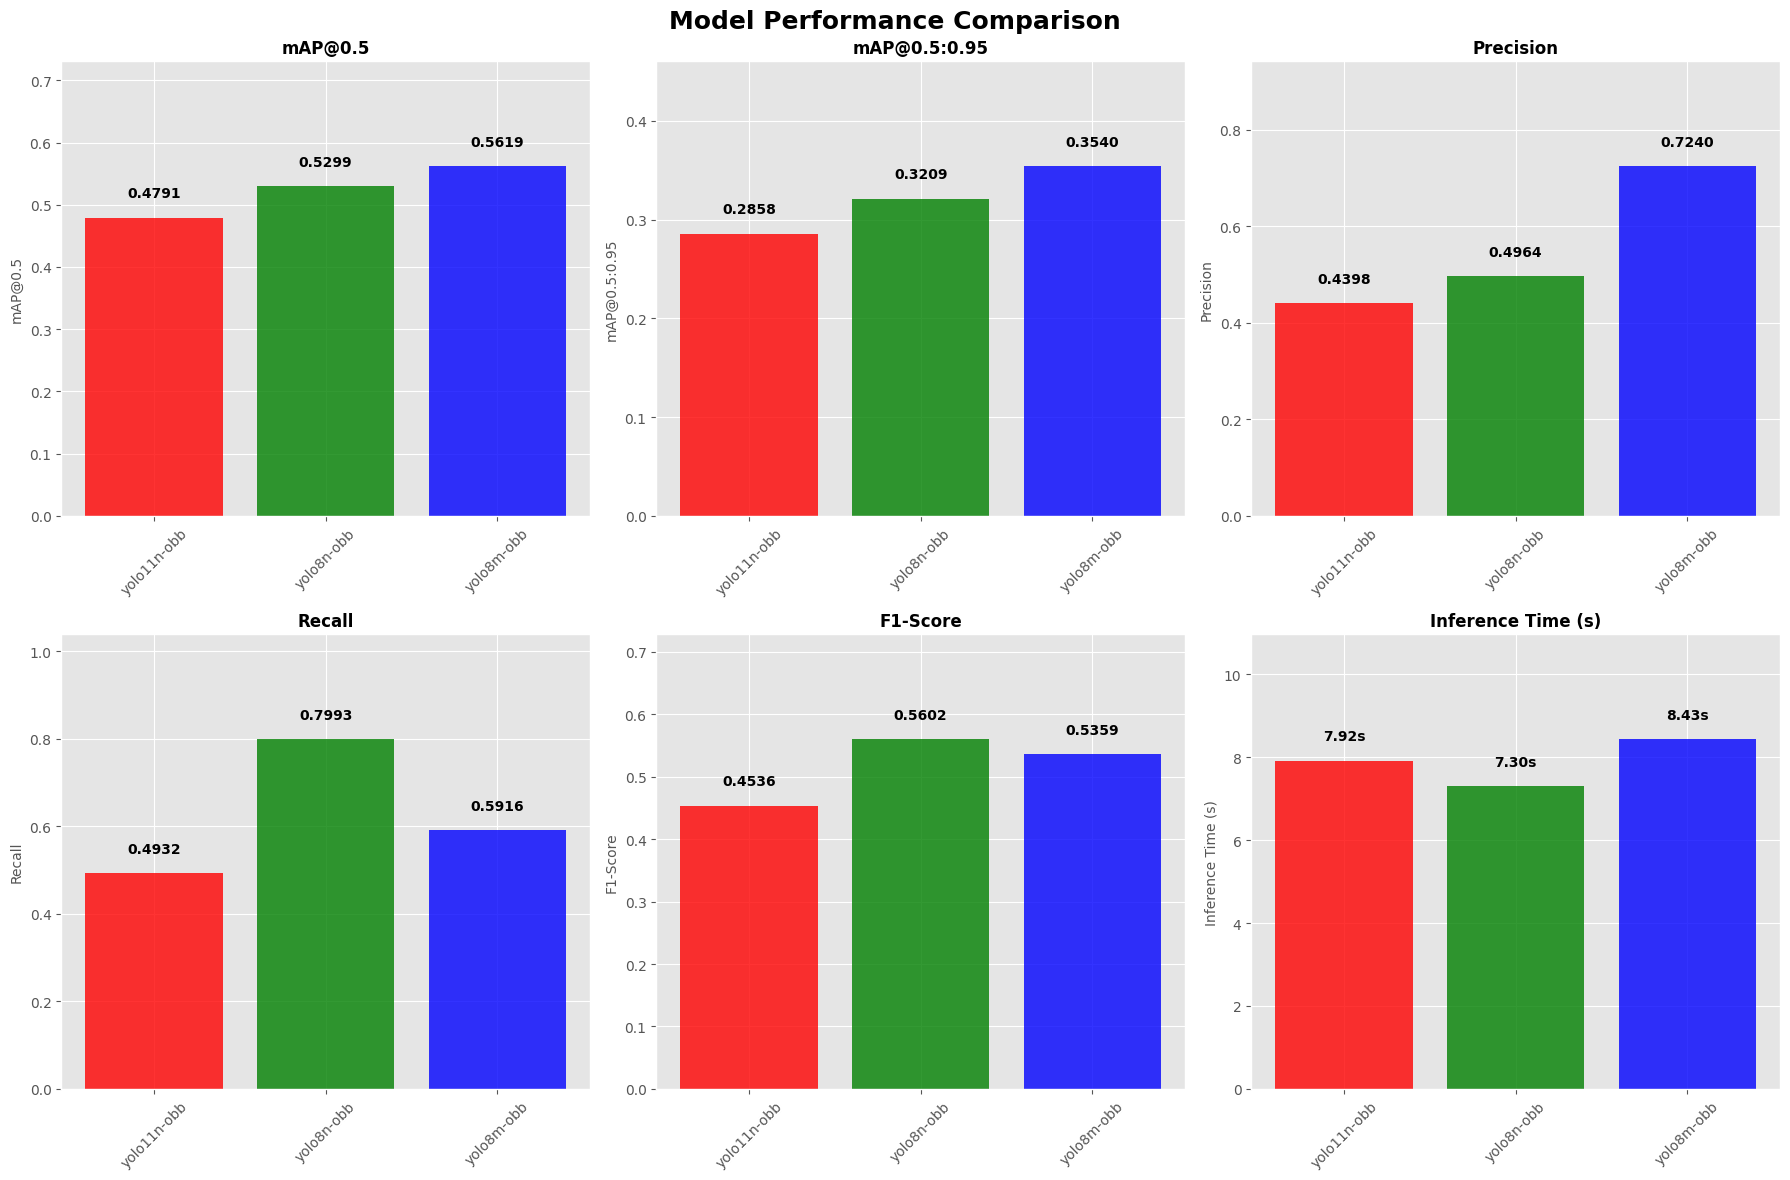

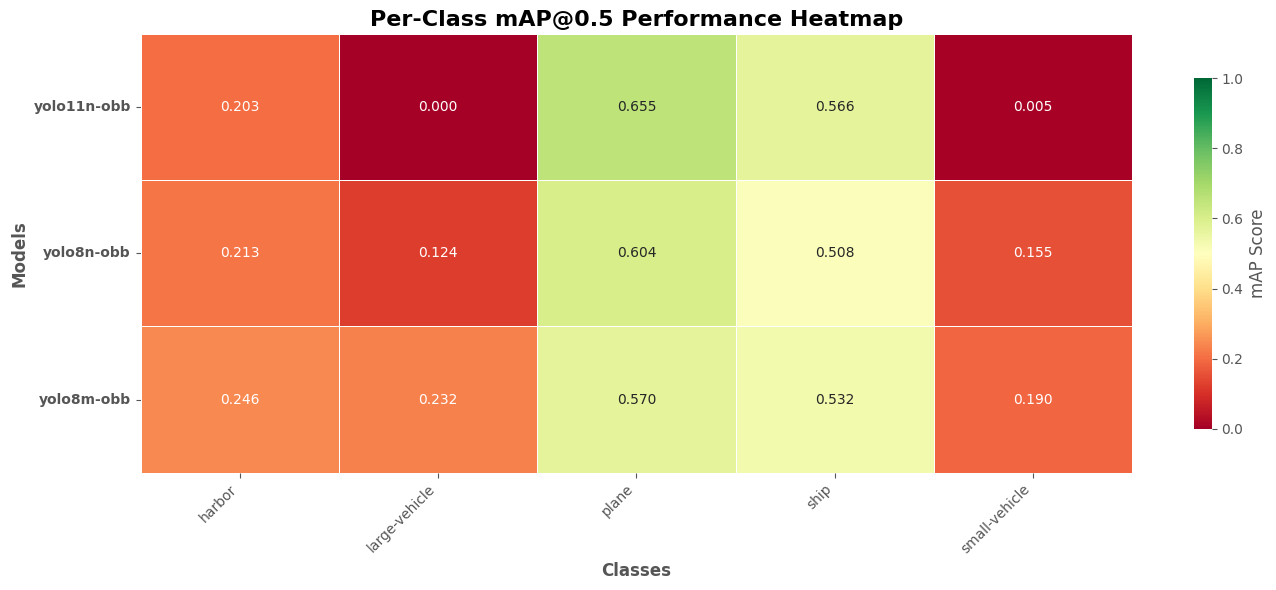

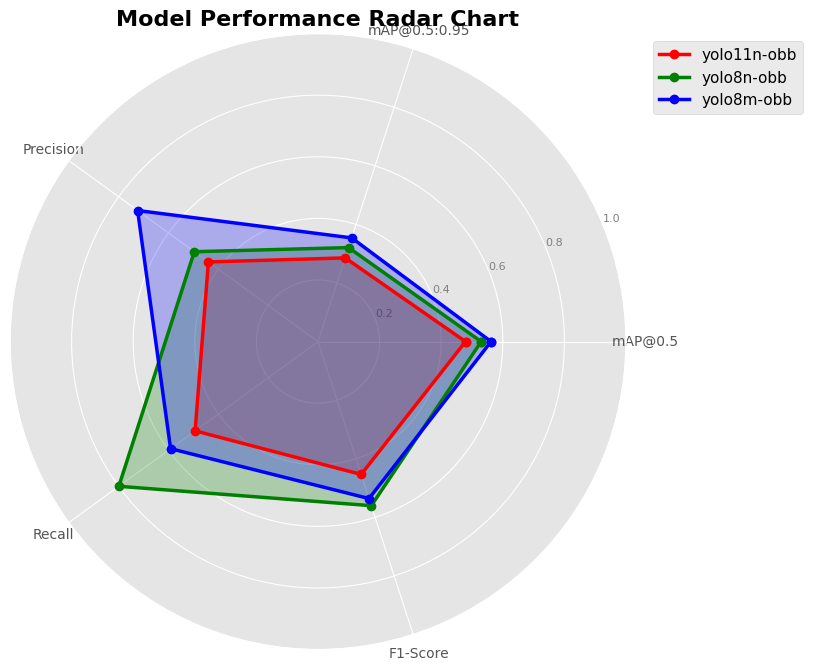

Setting the 'color' property will override the edgecolor or facecolor properties.
Setting the 'color' property will override the edgecolor or facecolor properties.


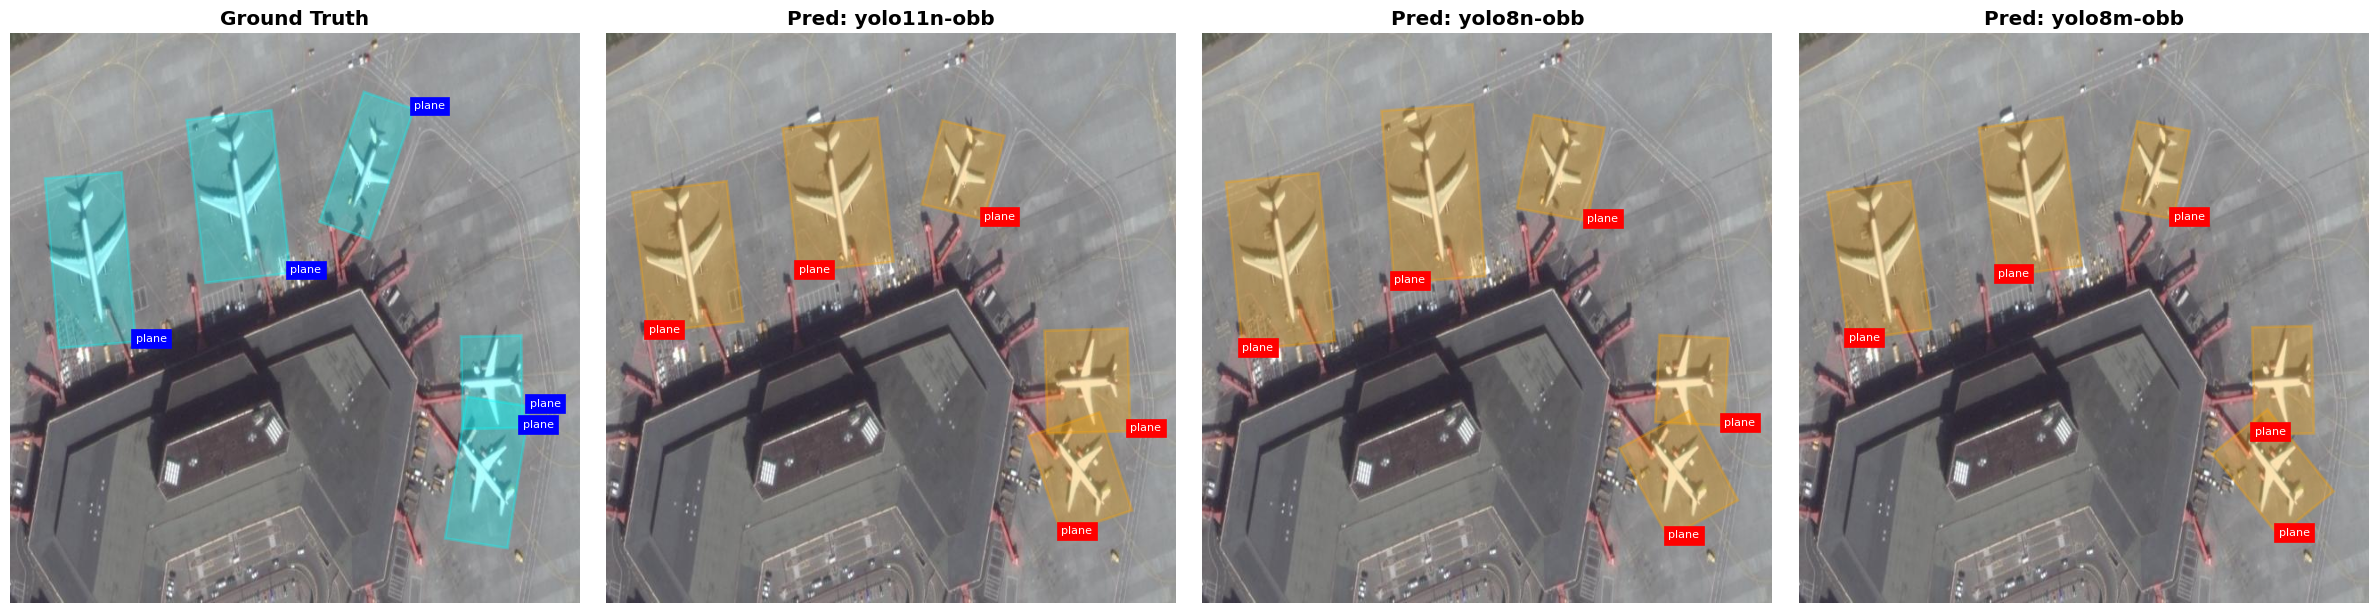

,Model,mAP@0.5,mAP@0.5:0.95,Precision,Recall,F1-Score,Inference Time (s)
0,yolo11n-obb,0.4791,0.2858,0.4398,0.4932,0.4536,7.917
1,yolo8n-obb,0.5299,0.3209,0.4964,0.7993,0.5602,7.302
2,yolo8m-obb,0.5619,0.3540,0.7240,0.5916,0.5359,8.433


In [ ]:
# TODO: Import additional libraries for evaluation and visualization
import random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from math import pi
import numpy as np
# TODO: Set visualization style
plt.style.use('ggplot')

# TODO: Load trained models from saved weights
trained_models = {
    'yolo11n-obb': None,
    'yolo8n-obb': None,
    'yolo8m-obb': None
}
# RESULT_DIR = f"{os.getcwd()}/results/"
for model_key, config in models_config.items():
    trained_models[model_key] = YOLO(config['save_dir'] + "/train/weights/best.pt")
# TODO: Evaluate each trained model:
evaluation_results = {
    'yolo11n-obb': None,
    'yolo8n-obb': None,
    'yolo8m-obb': None
}
# For each model_key, model in trained_models.items():
for model_key, model in trained_models.items():
    # TODO: Record evaluation start time
    starting_time = time.time()
    # TODO: Run model validation
    metrics = model.val(
        data=DATA_PATH,
        epochs=EPOCHS,
        batch=BATCH_SIZE,
        imgsz=IMG_SIZE
    )
    # TODO: Calculate evaluation time
    finishing_time = time.time()
    # in seconds
    evaluation_time = (finishing_time - starting_time)
    # TODO: Extract metrics from results
    model_metrics = {
      "mAP50_95": metrics.box.map,
      "mAP50": metrics.box.map50,
      "precision": metrics.box.mp,
      "recall": metrics.box.mr,
      "f1_score": np.mean(metrics.box.f1) if isinstance(metrics.box.f1, np.ndarray) else metrics.box.f1, # Ensure F1 is scalar
      "inference time": evaluation_time,
      "map_per_class": metrics.maps,
      "class_names": metrics.names
    }
    # TODO: Store metrics in evaluation_results[model_key]
    evaluation_results[model_key] = model_metrics
# TODO: Create Model Comparison Bar Plot
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
# add a centered title for the whole picture
fig.suptitle('Model Performance Comparison', fontsize=18, fontweight='bold')

# TODO: For each metric subplot:
#       - Extract values for all models
#       - Create bar chart with different colors
#       - Add value labels on top of bars
#       - Set appropriate titles and labels
#       - Rotate x-axis labels if needed
models = ['yolo11n-obb', 'yolo8n-obb', 'yolo8m-obb']
subtitles = ['mAP50', 'mAP50_95', 'precision', 'recall', 'f1_score', 'inference time'] # Changed 'F1' to 'f1_score'
colors = ('red', 'green', 'blue')
for idx, subtitle in enumerate(subtitles):
    ax = axes.flat[idx]
    # Extract values for all models
    values = []
    for model_name_key in models:
        value = evaluation_results[model_name_key][subtitle]
        values.append(value)

    # create bar chart with different colors
    bars = ax.bar(models, values, color=colors, alpha=0.8, linewidth=0.5)
    # add value labels on the top of bars
    for bar, value in zip(bars, values):
        if subtitle == 'inference time':
            label = f'{value:.2f}s'
        else:
            label = f'{value:.4f}'
        ax.text(bar.get_x() + bar.get_width()/2, value + (max(values)*0.05), label, # Adjusted label position
                ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

    # - Set appropriate titles and labels
    if subtitle == 'mAP50':
        title = 'mAP@0.5'
    elif subtitle == 'mAP50_95':
        title = 'mAP@0.5:0.95'
    elif subtitle == 'precision':
        title = 'Precision'
    elif subtitle == 'recall':
        title = 'Recall'
    elif subtitle == 'f1_score': # Changed 'F1' to 'f1_score'
        title = 'F1-Score'
    elif subtitle == 'inference time':
        title = 'Inference Time (s)'
    else:
        title = 'None'
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(title, fontsize=10)
    ax.set_ylim(0, max(values) * 1.3)

    # - Rotate x-axis labels if needed
    ax.set_xticklabels(models, rotation=45, fontsize=10)

plt.tight_layout()
plt.show()

# TODO: Create Per-Class Performance Heatmap
data_matrix = []
class_names = []

# Get class names from one of the models (they should be consistent)
if models:
    first_model_key = models[0]
    if first_model_key in evaluation_results and 'class_names' in evaluation_results[first_model_key]:
        class_names = list(evaluation_results[first_model_key]['class_names'].values())

for model_name_key in models:
    row = []
    if model_name_key in evaluation_results and 'map_per_class' in evaluation_results[model_name_key]:
        # Ultralytics returns map_per_class as an array, make sure it aligns with class_names
        per_class_maps = evaluation_results[model_name_key]['map_per_class']
        if len(per_class_maps) == len(class_names):
            row = per_class_maps.tolist()
        else:
            # If dimensions don't match, fill with NaN, and print a warning
            print(f"Warning: Class name count ({len(class_names)}) does not match per-class mAP count ({len(per_class_maps)}) for {model_name_key}")
            row = [np.nan] * len(class_names)
    data_matrix.append(row)

# convert to numpy
data_array = np.array(data_matrix)

fig, ax = plt.subplots(figsize=(14, 6))
heatmap = sns.heatmap(data_array,
                      annot=True,
                      fmt='.3f',          # precision
                      cmap='RdYlGn',      # color: red, yellow, green
                      vmin=0.0,
                      vmax=1.0,
                      center=0.5,
                      square=False,
                      linewidths=0.5,
                      linecolor='white',
                      cbar_kws={'label': 'mAP Score', 'shrink': 0.8},
                      ax=ax)
# set the axis
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(models, rotation=0, fontsize=10, fontweight='bold')
ax.set_title('Per-Class mAP@0.5 Performance Heatmap', fontsize=16, fontweight='bold')
ax.set_xlabel('Classes', fontsize=12, fontweight='bold')
ax.set_ylabel('Models', fontsize=12, fontweight='bold')
plt.tight_layout()
# show the img
plt.show()

# TODO: Implement create_radar_chart function
def create_radar_chart(results):
    num_metrics = 5
    # calculate the angle between each aspect
    angle = 2 * pi / num_metrics
    angles = [(angle * i) for i in (0, 1, 2, 3, 4)]

    # Make a complete circle by appending the first angle to the end
    angles = np.concatenate((angles, [angles[0]]))

    # starting plot the chart
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True))
    labels = ['mAP50', 'mAP50_95', 'precision', 'recall', 'f1_score'] # Changed 'F1' to 'f1_score'
    for idx, model_name_key in enumerate(models):
        values = []
        for label in labels:
            values.append(results[model_name_key].get(label))
        values += [values[0]] # Close the loop for radar chart
        ax.plot(angles, values, label=model_name_key,
                color=colors[idx % len(colors)],
                linewidth=2.5,
                marker='o'
                )
        ax.fill(angles, values, alpha=0.25, color=colors[idx % len(colors)])
    # set ticks (x-axis)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(['mAP@0.5', 'mAP@0.5:0.95', 'Precision', 'Recall', 'F1-Score'], fontsize=10)
    # set ticks (y-axis)
    ax.set_ylim(0, 1.0)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8, color="grey")

    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=11)
    ax.set_title('Model Performance Radar Chart',
                 fontsize=16, fontweight='bold')
    # show the fig
    plt.show()
# TODO: Call create_radar_chart with evaluation_results
create_radar_chart(evaluation_results)
# TODO: Implement plot_predictions_comparison function
def plot_model_comparisons(dataset, models_dict, num_samples=3):
    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))

    for idx in indices:
        sample = dataset[idx]
        img_path = sample['image_path']
        orig_img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)

        # Create a grid: Ground Truth + N Models
        num_plots = len(models_dict) + 1
        fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 6))

        # 1. Plot Ground Truth
        axes[0].imshow(orig_img)
        axes[0].set_title("Ground Truth", fontweight='bold')
        for ann in sample['annotations']:
            pts = np.array(ann['pixel_coords']).reshape(4, 2)
            poly = plt.Polygon(pts, closed=True, fill=True, color='cyan', alpha=0.3, linewidth=2, edgecolor='blue') # Added closed=True
            axes[0].add_patch(poly)
            # Add label
            axes[0].text(pts[0][0], pts[0][1], ann['class_name'], # Use first point for label
                         color='white', backgroundcolor='blue', fontsize=8)
        axes[0].axis('off')

        # 2. Plot Predictions for each model
        for i, (name, model) in enumerate(models_dict.items()):
            ax = axes[i+1]
            ax.imshow(orig_img)
            ax.set_title(f"Pred: {name}", fontweight='bold')

            # Run inference
            # Use a slightly lower confidence threshold for visualization if needed
            results = model.predict(str(img_path), imgsz=640, conf=0.25, verbose=False) # Changed img_path to str(img_path)

            if results and len(results[0].obb) > 0:
                # results[0].obb.xyxyxyxy contains the 4 corner points (N, 8) format
                obb_data = results[0].obb.xyxyxyxy.cpu().numpy()
                cls_data = results[0].obb.cls.cpu().numpy()

                for box, cls_id in zip(obb_data, cls_data):
                    # Reshape to (4, 2) for plt.Polygon
                    box_reshaped = box.reshape(4, 2)
                    poly = plt.Polygon(box_reshaped, closed=True, fill=True, color='orange', alpha=0.3, linewidth=2, edgecolor='red') # Added closed=True
                    ax.add_patch(poly)
                    # Add label
                    ax.text(box_reshaped[0][0], box_reshaped[0][1], dataset.class_names[int(cls_id)],
                            color='white', backgroundcolor='red', fontsize=8)

            ax.axis('off')

        plt.tight_layout()
        plt.show()
# TODO: Visualize predictions on test images
plot_model_comparisons(test, trained_models, num_samples=1)
# TODO: Create Performance Summary Table
def create_performance_summary(results):
    summary_data = []
    for model_name, metrics in results.items():
        summary_data.append({
            'Model': model_name,
            'mAP@0.5': f"{metrics['mAP50']:.4f}",
            'mAP@0.5:0.95': f"{metrics['mAP50_95']:.4f}",
            'Precision': f"{metrics['precision']:.4f}",
            'Recall': f"{metrics['recall']:.4f}",
            'F1-Score': f"{metrics['f1_score']:.4f}",
            'Inference Time (s)': f"{metrics['inference time']:.3f}"
        })

    df_summary = pd.DataFrame(summary_data)
    return df_summary

# Generate and display the table
performance_df = create_performance_summary(evaluation_results)
display(performance_df)

## 📝 Evaluation Criteria

Your homework will be evaluated based on:

### 1. Implementation Correctness (40%)
- **Dataset Class**: Proper OBB annotation parsing and coordinate conversion
- **YOLO Integration**: Correct usage of Ultralytics YOLO models for OBB detection
- **Training Pipeline**: Working training loop with proper hyperparameter configuration
- **Evaluation Metrics**: Accurate implementation of mAP calculation for oriented boxes
- **Visualization**: Correct display of oriented bounding boxes and predictions

### 2. Model Training and Performance (30%)
- **Multi-Model Training**: Successfully training all 3 YOLO variants
- **Convergence**: Reasonable training progress and metric improvement
- **Performance Analysis**: Meaningful comparison between different model architectures
- **Results Quality**: Achieving acceptable detection performance on test set
- **Efficiency Analysis**: Proper comparison of training time and inference speed

### 3. Code Quality and Analysis (20%)
- **Code Structure**: Clean, readable code with proper organization
- **Documentation**: Adequate comments explaining OBB concepts and implementation
- **Comparative Analysis**: Thoughtful comparison of model performance and trade-offs

### 4. Visualization and Presentation (10%)
- **Chart Quality**: Professional and informative performance comparison plots
- **Prediction Visualization**: Clear display of oriented bounding box predictions
- **Results Interpretation**: Meaningful analysis of model strengths and weaknesses
- **Technical Communication**: Clear explanation of OBB detection concepts

## 🎯 Expected Performance Benchmarks
- **Minimum mAP@0.5**: > 0.30 (at least one model should achieve this)
- **Training Completion**: All models should train without errors
- **Visualization Quality**: Clear, labeled plots with proper oriented box rendering
- **Comparative Analysis**: Identify best performing model with justification